PACKAGE IMPORTS

In [165]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ASSISTANT FUNCTIONS

In [166]:
def draw_histogram(df,col):
    # BIN DETERMINATIONS
    # if df[col].nunique() < 10:
    #     nBins = df[col].nunique()
    # el
    if df[col].dtype == int or df[col].dtype == float:
        # FREEDMAN-DRACONIS RULE
        data = df[col]
        range = data.max() - data.min()
        iqr = np.percentile(df[col],75) - np.percentile(df[col],25)
        n = data.size
        width = (2 * iqr) / n**(1/3)
        nBins = math.ceil(range / width)
        # print("Column = ",col)
        # print('Range = ',range,'IQR = ',iqr,'N = ',n,'Width = ',width,'nBins = ',nBins)
    elif df[col].dtype == object:
        nBins = df[col].nunique()
    
    # PLOT RESULTS
    plt.figure(figsize=(5,2))
    plt.hist(df[col], bins=nBins, color='teal', edgecolor='black')
    plt.title('Distribution of '+col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    # print(list(df[col].unique()),"\n")

# DATA PREPARATION

In [ ]:
# LOAD DATASET
url = 'https://raw.githubusercontent.com/mnorton365/Python/refs/heads/main/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(url)

# INITIAL OVERVIEW (HEADER, SHAPE, INFO)
print('\033[4m'+'DataFrame Headers:'+'\033[0m')
display(df.head())

print('\033[4m'+'Shape:'+'\033[0m')
print(f'Row Count:               {df.shape[0]:,}')
print(f'Row Count (Duplicates):  {df.duplicated().sum():,}')
print(f'Columnn Count:           {df.shape[1]:,}')

print('\n\033[4m'+'DataFrame Info:'+'\033[0m')
bdfi = pd.DataFrame({
    'columns': df.columns,
    'data_type': df.dtypes,
    'non-null_count': df.count().values,
    'null_count': df.isna().sum(),
    'unique_count': df.nunique()
}).reset_index(drop=True)
bdfi = bdfi.set_index('columns').rename_axis(None, axis=0)
display(bdfi)

# DATA TYPES
print('\n\033[4m'+'DataFrame Info:'+'\033[0m')
df['id'] = df['id'].astype(str)
df['bmi'] = pd.to_numeric(df['bmi'],errors='coerce')

# WORKSPACE

# HISTOGRAM VISUALIZATIONS
# for x in df:
#     draw_histogram(df,x)

DataFrame Headers:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,.,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24,never smoked,1


Shape:
Row Count:               5,110
Row Count (Duplicates):  0
Columnn Count:           12

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   object 
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 479.2+ KB

DataFrame Info:


,data_type,non-null_count,null_count,unique_count
id,object,5110,0,5110
gender,object,5110,0,3
age,float64,5110,0,104
hypertension,int64,5110,0,2
heart_disease,int64,5110,0,2
ever_married,object,5110,0,2
work_type,object,5110,0,5
Residence_type,object,5110,0,2
avg_glucose_level,float64,5110,0,3979
bmi,float64,4909,201,418


### MISSING VALUES

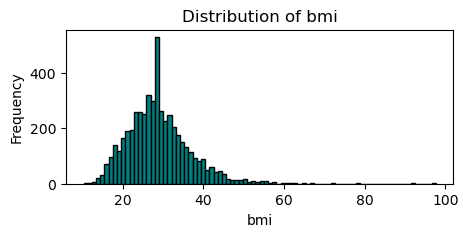

In [168]:
df['imp_bmi'] = df['bmi'].isna()
imp_mean_bmi = df['bmi'].mask(df['bmi'] == 0).mean()
df['bmi'] = df['bmi'].fillna(imp_mean_bmi)
draw_histogram(df,"bmi")


# better_df_info(df)